In [22]:
import pyxtal
from pyxtal import pyxtal
from pymatgen.ext.matproj import MPRester
import crystal_toolkit
import wulffpack 
from wulffpack import SingleCrystal
from ase.io import write, read
from ase.build import bulk
from ase.build import surface
from ase.visualize import view

información rayos x

In [6]:
mpr = MPRester("YVb1EJfpW6q8GgufwhezGRB7YsGcbEXS")
complete_material = mpr.get_structure_by_material_id("mp-81")
complete_material

/home/eligran12/anaconda3/envs/crystals/lib/python3.11/site-packages/mp_api/client/mprester.py:193: UserWarning: mpcontribs-client not installed. Install the package to query MPContribs data, or construct pourbaix diagrams: 'pip install mpcontribs-client'
  warnings.warn(
Retrieving MaterialsDoc documents: 100%|████████████████████████████████████████████████| 1/1 [00:00<00:00, 6668.21it/s]


If you see this text, the Crystal Toolkit Jupyter Lab 

extension is not installed. You can install it by running 

"pip install crystaltoolkit-extension" 

from the same environment you run "jupyter lab". 

This only works in Jupyter Lab 3.x or above.


Structure Summary
Lattice
    abc : 2.9495462029697044 2.9495467521426066 2.949546
 angles : 60.00000843542354 60.000002276344645 60.00000120154803
 volume : 18.14473805188449
      A : 2.554382 0.0 1.474773
      B : 0.851461 2.408295 1.474773
      C : 0.0 0.0 2.949546
    pbc : True True True
PeriodicSite: Au (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]

In [9]:
struc = pyxtal()
struc.from_seed(complete_material)
struc.get_XRD()

/home/eligran12/anaconda3/envs/crystals/lib/python3.11/site-packages/pyxtal/XRD.py:124: RuntimeWarning: divide by zero encountered in scalar divide
  d_max = self.wavelength/np.sin(self.min2theta/2)/2


  2theta     d_hkl     hkl       Intensity  Multi
  37.339     2.408   [ 1  1  1]   100.00        8
  43.386     2.086   [ 2  0  0]    49.57        6
  63.032     1.475   [ 2  2  0]    33.16       12
  75.608     1.258   [ 3  1  1]    39.83       24
  79.617     1.204   [ 2  2  2]    11.69        8
  95.337     1.043   [ 4  0  0]     6.36        6
 107.335     0.957   [ 3  3  1]    23.96       24
 111.486     0.933   [ 4  2  0]    24.25       24
 129.757     0.851   [ 4  2  2]    29.85       24
 147.615     0.803   [ 5  1  1]    60.67       24

In [13]:
E_surf = {(1,1,1): 2.5 , (5,1,1): 2.6 , (2,0,0): 2.4 }
bulk_au = bulk("Au", crystalstructure= "fcc", a=4.17, cubic=True)

In [14]:
particle = SingleCrystal(E_surf, bulk_au, natoms = 1000)
particle

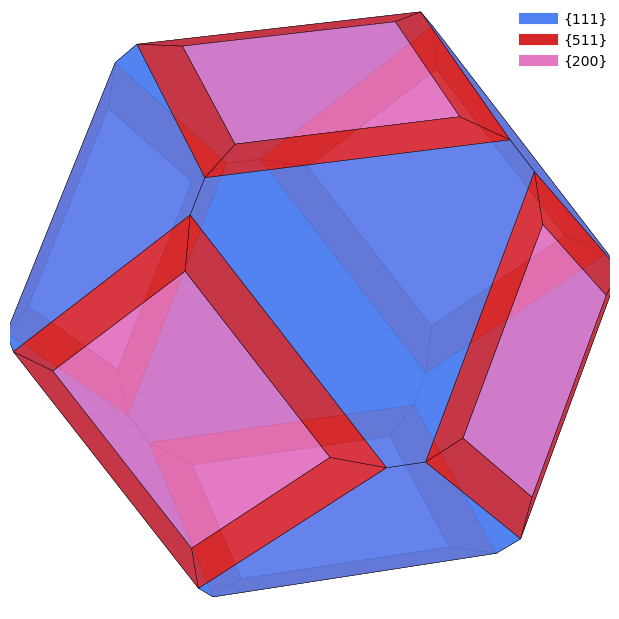

In [16]:
particle.view()

In [17]:
write("particle.xyx", particle.atoms)

In [19]:
complete_material.to("bulk_au.cif")

"# generated using pymatgen\ndata_Au\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   2.94954620\n_cell_length_b   2.94954675\n_cell_length_c   2.94954600\n_cell_angle_alpha   60.00000844\n_cell_angle_beta   60.00000228\n_cell_angle_gamma   60.00000120\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   Au\n_chemical_formula_sum   Au1\n_cell_volume   18.14473805\n_cell_formula_units_Z   1\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Au  Au0  1  0.00000000  0.00000000  0.00000000  1\n"

In [21]:
#contruir slab para el au
bulk_au = read("bulk_au.cif") #celda unitaria del au

In [25]:
surface_1_1_1 = surface(bulk_au, (1,1,1), 4, vacuum = 10)
view(surface_1_1_1) #celda unitaria de la superficie

<Popen: returncode: None args: ['/home/eligran12/anaconda3/envs/crystals/bin...>

In [27]:
view(bulk_au)

<Popen: returncode: None args: ['/home/eligran12/anaconda3/envs/crystals/bin...>

In [28]:
#super celda
surface_2x2 = surface_1_1_1 * [2, 2, 1]
view(surface_2x2)

<Popen: returncode: None args: ['/home/eligran12/anaconda3/envs/crystals/bin...>

In [29]:
surface_4x4 = surface_1_1_1 * [4, 4, 1]
view(surface_4x4)

<Popen: returncode: None args: ['/home/eligran12/anaconda3/envs/crystals/bin...>